# Cambios del Script $22/06/26$
- ### Se agrega un Ansatz con la condicion inicial
- ### Dado el Ansatz se quita $Loss_{ic}$
- ### Cinco Capas ocultas con 72 neuronas y SWISH cada una  

In [1]:
# ============================================================
# PINN para lahar por etapas (z_b fijo, sin Exner)
# Aprende: h, u, v, C, p
# ============================================================
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, optimizers
import matplotlib.pyplot as plt
tf.random.set_seed(7)
np.random.seed(7)

2026-07-07 14:58:47.717351: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-07 14:58:47.772692: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/djara/miniconda3/envs/tf216/lib/python3.11/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
# ============================================================
# SELECCIÓN DE TOPOGRAFÍA
# ============================================================
TOPO_SCENARIO = 2 # 1: plano inclinado, 2: valle gaussiano, 3: canal sinuoso
# ============================================================
# 1) PARÁMETROS FÍSICOS
# ============================================================
g = 9.81
rho_m = 1800.0
mu0 = 0.20
alpha_C = 1.2
alpha_p = 4.0
C0 = 0.45
p_ref = 1e4
kappa_C = 5.0
tau_C = 1e9 # relajación casi nula para C
tau_p = 120.0
chi_p = 0.35
u_star = 1.0
C_star = 0.05
eps_u = 1e-3
eps_h = 1e-6
# ============================================================
# 2) DOMINIO
# ============================================================
Lx = 10_000.0
Ly = 2_000.0
Tmax = 1200.0
x_min, x_max = 0.0, Lx
y_min, y_max = -Ly/2, Ly/2
t_min, t_max = 0.0, Tmax
# Normalización
x_scale = Lx
y_scale = Ly/2
t_scale = Tmax
h_scale = 10.0
u_scale = 10.0
p_scale = rho_m * g * h_scale

In [3]:
# ============================================================
# 3) TOPOGRAFÍA FIJA z_b(x,y)
# ============================================================
def zb0_physical(x, y):
    if TOPO_SCENARIO == 1:
        # Plano inclinado (Pendiente 10%) - Usar solo para calibrar
        Sx = 0.10
        z0 = 3000.0
        return z0 - Sx * x

    elif TOPO_SCENARIO == 2:
        # Valle Parabólico Suave (Aproximación Villarrica / Quebrada)
        Sx = 0.08         # Pendiente longitudinal (8%)
        z0 = 2900.0       # Altitud base
        
        # Curvatura del valle. 
        # A y=1000m, las paredes suben 50 metros respecto al centro.
        # Esto confina el flujo sin generar gradientes explosivos.
        k_y = 50.0 / (1000.0**2) 
        
        return (z0 - Sx * x) + k_y * (y**2)

    else:
        # Valle Convergente (Embudamiento)
        # El canal se hace más estrecho a medida que se desciende
        Sx = 0.08
        z0 = 2900.0
        # La pendiente transversal aumenta linealmente con 'x'
        k_y = (20.0 + 0.01 * x) / (1000.0**2) 
        return (z0 - Sx * x) + k_y * (y**2)

def grad_zb_fixed(x, y):
    """
    Gradiente de la topografía fija.
    Se calcula aparte para evitar NoneType en Graph mode.
    """
    with tf.GradientTape(persistent=True) as tape:
        tape.watch([x, y])
        zb = zb0_physical(x, y)
    zb_x = tape.gradient(zb, x)
    zb_y = tape.gradient(zb, y)
    del tape
    return zb_x, zb_y

# ============================================================
# 4) CONDICIONES INICIALES
# ============================================================
def ic_h_physical(x, y):
    x0, y0 = 1200.0, 0.0
    sigx, sigy = 900.0, 450.0
    h0 = 8.0
    return h0 * tf.exp(-((x - x0)**2 / (2 * sigx**2) + (y - y0)**2 / (2 * sigy**2)))

def ic_u_physical(x, y):
    return tf.zeros_like(x)

def ic_v_physical(x, y):
    return tf.zeros_like(y)

def ic_C_physical(x, y):
    C_bg = 0.35 #Minimo
    C_peak = 0.25
    x0, y0 = 1200.0, 0.0
    sigx, sigy = 1000.0, 550.0
    C = C_bg + C_peak * tf.exp(-((x - x0)**2 / (2 * sigx**2) + (y - y0)**2 / (2 * sigy**2)))
    return tf.clip_by_value(C, 0.2, 0.75)

def ic_p_physical(x, y):
    return 0.2 * rho_m * g * ic_h_physical(x, y)


# ============================================================
# 5) MUESTREO DE PUNTOS
# ============================================================
N_ic = 4000
N_pde = 30000
N_bc = 4000

# IC (t=0)
x_ic = tf.random.uniform((N_ic, 1), x_min, x_max, dtype=tf.float32)
y_ic = tf.random.uniform((N_ic, 1), y_min, y_max, dtype=tf.float32)
t_ic = tf.zeros_like(x_ic)

h_ic = ic_h_physical(x_ic, y_ic)
u_ic = ic_u_physical(x_ic, y_ic)
v_ic = ic_v_physical(x_ic, y_ic)
C_ic = ic_C_physical(x_ic, y_ic)
p_ic = ic_p_physical(x_ic, y_ic)

# PDE collocation
x_pde = tf.random.uniform((N_pde, 1), x_min, x_max, dtype=tf.float32)
y_pde = tf.random.uniform((N_pde, 1), y_min, y_max, dtype=tf.float32)
t_pde = tf.random.uniform((N_pde, 1), t_min, t_max, dtype=tf.float32)

# BC laterales
x_bc = tf.random.uniform((N_bc, 1), x_min, x_max, dtype=tf.float32)
t_bc = tf.random.uniform((N_bc, 1), t_min, t_max, dtype=tf.float32)
y_bc_top = tf.ones_like(x_bc) * y_max
y_bc_bot = tf.ones_like(x_bc) * y_min

2026-07-07 14:58:51.853838: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-07-07 14:58:51.949539: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-07-07 14:58:51.949649: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-07-07 14:58:51.951541: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-07-07 14:58:51.951576: I external/local_xla/xla/stream_executor

In [4]:
# ============================================================
# 6) RED NEURONAL: (x,y,t) -> (h,u,v,C) (CON ANSATZ EXACTO)
# ============================================================
Cmax = 0.85

inputs = tf.keras.Input(shape=(3,))
x = layers.Dense(72, activation='swish')(inputs)
x = layers.Dense(72, activation='swish')(x)
x = layers.Dense(72, activation='swish')(x)
x = layers.Dense(72, activation='swish')(x)
x = layers.Dense(72, activation='swish')(x)
x = layers.Dense(72, activation='swish')(x)
out_raw = layers.Dense(4, activation='linear')(x)

model = tf.keras.Model(inputs=inputs, outputs=out_raw)

lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=1e-3,
    decay_steps=3000,      
    decay_rate=0.85,        
    staircase=False
)
opt = tf.keras.mixed_precision.LossScaleOptimizer(tf.keras.optimizers.Adam(learning_rate=lr_schedule, clipnorm=1.0))

@tf.function
def predict_fields(xm, ym, tm):
    xn = xm / x_scale
    yn = ym / y_scale
    tn = tm / t_scale
    inp = tf.concat([xn, yn, tn], axis=1)
    raw = model(inp)

    h_raw = raw[:, 0:1]
    u_raw = raw[:, 1:2]
    v_raw = raw[:, 2:3]
    C_raw = raw[:, 3:4]

    h0 = ic_h_physical(xm, ym)
    u0 = ic_u_physical(xm, ym)
    v0 = ic_v_physical(xm, ym)
    C0_ic = ic_C_physical(xm, ym)

    omega = 1.0 - tf.exp(-5.0 * tn)

    u = u0 + omega * (u_raw * u_scale)
    v = v0 + omega * (v_raw * u_scale)

    # Blindaje h: Evitar log(0)
    clip_h = tf.clip_by_value(1.0 - tf.exp(-h0), 1e-7, 1.0)
    inv_sp_h0 = h0 + tf.math.log(clip_h)
    h = tf.nn.softplus(inv_sp_h0 + omega * h_raw * h_scale)

    # Blindaje C: Evitar log(0) con clip_by_value
    C0_norm = tf.clip_by_value(C0_ic / Cmax, 1e-7, 1.0 - 1e-7)
    inv_sig_C0 = tf.math.log(C0_norm / (1.0 - C0_norm))
    C = Cmax * tf.math.sigmoid(inv_sig_C0 + omega * C_raw)

    return h, u, v, C

In [5]:
# ============================================================
# 7) CIERRES FÍSICOS
# ============================================================
@tf.function
def mu_eff(C, p, h):
    denom = rho_m * g * h + p_ref
    return mu0 * (1.0 + alpha_C * (C - C0)) * tf.exp(-alpha_p * (p / denom))

@tf.function
def cos_theta(zb_x, zb_y):
    return 1.0 / tf.sqrt(1.0 + zb_x**2 + zb_y**2)

@tf.function
def p_eq(h, C, u, v):
    speed = tf.sqrt(u**2 + v**2 + eps_u)
    phiC = C / (C + C_star)
    return chi_p * rho_m * g * h * phiC * (speed / (speed + u_star))

# ============================================================
# 8) RESIDUOS PDE (SIN Exner, z_b FIJO)
# ============================================================
@tf.function
def pde_residuals(xm, ym, tm):
    # Primer y segundo orden para h,u,v,C,p
    with tf.GradientTape(persistent=True) as tape2:
        tape2.watch([xm, ym, tm])
        with tf.GradientTape(persistent=True) as tape1:
            tape1.watch([xm, ym, tm])

            h, u, v, C = predict_fields(xm, ym, tm)
            zb = zb0_physical(xm, ym)
            H = h + zb
            hu = h * u
            hv = h * v

        # 1er orden
        h_t = tape1.gradient(h, tm)
        hu_x = tape1.gradient(hu, xm)
        hv_y = tape1.gradient(hv, ym)

        u_t = tape1.gradient(u, tm)
        u_x = tape1.gradient(u, xm)
        u_y = tape1.gradient(u, ym)

        v_t = tape1.gradient(v, tm)
        v_x = tape1.gradient(v, xm)
        v_y = tape1.gradient(v, ym)

        H_x = tape1.gradient(H, xm)
        H_y = tape1.gradient(H, ym)

        C_t = tape1.gradient(C, tm)
        C_x = tape1.gradient(C, xm)
        C_y = tape1.gradient(C, ym)

    # 2do orden
    C_xx = tape2.gradient(C_x, xm)
    C_yy = tape2.gradient(C_y, ym)

    del tape1
    del tape2

    # Gradiente topografía fija (separado)
    zb_x, zb_y = grad_zb_fixed(xm, ym)

    # Seguridad extra por si alguna derivada sale None
    if C_xx is None:
        C_xx = tf.zeros_like(xm)
    if C_yy is None:
        C_yy = tf.zeros_like(ym)
    if zb_x is None:
        zb_x = tf.zeros_like(xm)
    if zb_y is None:
        zb_y = tf.zeros_like(ym)

    # (1) Masa
    S_h = 0.0
    f_mass = h_t + hu_x + hv_y - S_h

    # Fricción basal
    p_alg = p_eq(h, C, u, v)
    speed = tf.sqrt(u**2 + v**2 + eps_u)
    mu = mu_eff(C, p_alg, h)
    cth = cos_theta(zb_x, zb_y)

    tau_b = mu * rho_m * g * h * cth
    tau_bx = tau_b * (u / (speed + eps_u))
    tau_by = tau_b * (v / (speed + eps_u))

    # (2) Momento x
    f_momx = u_t + u * u_x + v * u_y + g * H_x + tau_bx / (rho_m * (h + eps_h))

    # (3) Momento y
    f_momy = v_t + u * v_x + v * v_y + g * H_y + tau_by / (rho_m * (h + eps_h))


    # (4) Concentración
    C_eq_val = 0.45
    f_C = C_t + u * C_x + v * C_y - (kappa_C * (C_xx + C_yy) + (C_eq_val - C) / tau_C)


    return f_mass, f_momx, f_momy, f_C



In [6]:
# ============================================================
# 9) PÉRDIDAS
# ============================================================
# ============================================================
# PÉRDIDA DE FRONTERA (NEUMANN / OPEN BOUNDARY)
# ============================================================
@tf.function
def loss_bc():
    # 1. Necesitamos observar las coordenadas 'y' para poder derivar respecto a ellas
    with tf.GradientTape(persistent=True) as tape:
        tape.watch(y_bc_top)
        tape.watch(y_bc_bot)
        
        # Predicciones en la frontera superior
        h_top, u_top, v_top, C_top = predict_fields(x_bc, y_bc_top, t_bc)
        # Predicciones en la frontera inferior
        h_bot, u_bot, v_bot, C_bot = predict_fields(x_bc, y_bc_bot, t_bc)
        
    # 2. Gradientes normales (respecto a y) en la frontera superior
    dh_dy_top = tape.gradient(h_top, y_bc_top)
    du_dy_top = tape.gradient(u_top, y_bc_top)
    dv_dy_top = tape.gradient(v_top, y_bc_top)
    dC_dy_top = tape.gradient(C_top, y_bc_top)
    
    # 3. Gradientes normales (respecto a y) en la frontera inferior
    dh_dy_bot = tape.gradient(h_bot, y_bc_bot)
    du_dy_bot = tape.gradient(u_bot, y_bc_bot)
    dv_dy_bot = tape.gradient(v_bot, y_bc_bot)
    dC_dy_bot = tape.gradient(C_bot, y_bc_bot)
    
    del tape
    
    # Seguridad: Si alguna derivada es None, la volvemos cero
    if dh_dy_top is None: dh_dy_top = tf.zeros_like(y_bc_top)
    if dh_dy_bot is None: dh_dy_bot = tf.zeros_like(y_bc_bot)
    
    # 4. Minimizamos el cuadrado de los gradientes para forzarlos a ser 0
    # No es estrictamente necesario dividir por una escala aquí ya que el target es 0.0
    loss_top = (tf.reduce_mean(tf.square(dh_dy_top)) + 
                tf.reduce_mean(tf.square(du_dy_top)) + 
                tf.reduce_mean(tf.square(dv_dy_top)) + 
                tf.reduce_mean(tf.square(dC_dy_top)))
                
    loss_bot = (tf.reduce_mean(tf.square(dh_dy_bot)) + 
                tf.reduce_mean(tf.square(du_dy_bot)) + 
                tf.reduce_mean(tf.square(dv_dy_bot)) + 
                tf.reduce_mean(tf.square(dC_dy_bot)))
    
    return loss_top + loss_bot

@tf.function
def loss_pde_stage2(xb, yb, tb):
    f_mass, f_momx, f_momy, f_C = pde_residuals(xb, yb, tb)
    eps = 1e-8
    scale_mass = h_scale / t_scale
    scale_mom = u_scale / t_scale
    scale_C = Cmax / t_scale
    
    return (
        tf.reduce_mean(tf.square(f_mass / (scale_mass + eps))) +
        tf.reduce_mean(tf.square(f_momx / (scale_mom + eps))) +
        tf.reduce_mean(tf.square(f_momy / (scale_mom + eps))) +
        tf.reduce_mean(tf.square(f_C / (scale_C + eps)))
    )

@tf.function
def loss_pde_stage3(xb, yb, tb):
    # En tu arquitectura actual de 4 PDEs, Stage 2 y 3 tienen los mismos residuos
    return loss_pde_stage2(xb, yb, tb)


In [7]:
# ============================================================
# 10) ENTRENAMIENTO POR ETAPAS (Sin Etapa 1)
# ============================================================
pde_batch = 4096

# -------- ETAPA 2 (Ahora es tu inicio de entrenamiento) --------
epochs_stage2 = 5000
lambda_bc_2 = 20.0
lambda_pde_2 = 20.0

@tf.function
def train_step_stage2():
    idx = tf.random.uniform((pde_batch,), 0, N_pde, dtype=tf.int32)
    xb = tf.gather(x_pde, idx)
    yb = tf.gather(y_pde, idx)
    tb = tf.gather(t_pde, idx)

    with tf.GradientTape() as tape:
        Lbc = loss_bc()
        Lpde = loss_pde_stage2(xb, yb, tb)
        L = lambda_bc_2 * Lbc + lambda_pde_2 * Lpde
        
        # Escalamiento para LossScaleOptimizer
        scaled_loss = opt.scale_loss(L)
        
    scaled_grads = tape.gradient(scaled_loss, model.trainable_variables)
    opt.apply_gradients(zip(scaled_grads, model.trainable_variables))
    
    return L, Lbc, Lpde

print("\n==============================")
print("ETAPA 2: Ajuste de BC + Masa/Momento")
print("==============================")
for ep in range(epochs_stage2):
    L, Lbc, Lpde = train_step_stage2()
    if (ep + 1) % 100 == 0:
        print(f"[Stage 2] Epoch {ep+1}/{epochs_stage2} | Total {L.numpy():.3e} | BC {Lbc.numpy():.3e} | PDE {Lpde.numpy():.3e}")

# -------- ETAPA 3 --------
epochs_stage3 = 5000
lambda_bc_3 = 20.0
lambda_pde_3 = 100.0

@tf.function
def train_step_stage3():
    idx = tf.random.uniform((pde_batch,), 0, N_pde, dtype=tf.int32)
    xb = tf.gather(x_pde, idx)
    yb = tf.gather(y_pde, idx)
    tb = tf.gather(t_pde, idx)

    with tf.GradientTape() as tape:
        Lbc = loss_bc()
        Lpde = loss_pde_stage3(xb, yb, tb)
        L = lambda_bc_3 * Lbc + lambda_pde_3 * Lpde
        
        scaled_loss = opt.scale_loss(L)
        
    scaled_grads = tape.gradient(scaled_loss, model.trainable_variables)
    opt.apply_gradients(zip(scaled_grads, model.trainable_variables))
    
    return L, Lbc, Lpde

print("\n==============================")
print("ETAPA 3: BC + PDE Completas (Exigencia máxima)")
print("==============================")
for ep in range(epochs_stage3):
    L, Lbc, Lpde = train_step_stage3()
    if (ep + 1) % 100 == 0:
        print(f"[Stage 3] Epoch {ep+1}/{epochs_stage3} | Total {L.numpy():.3e} | BC {Lbc.numpy():.3e} | PDE {Lpde.numpy():.3e}")

print("\nEntrenamiento completado. ¡Tu Condición Inicial está intacta por construcción!")


ETAPA 2: Ajuste de BC + Masa/Momento
[Stage 2] Epoch 100/5000 | Total 1.446e+04 | BC 1.323e-05 | PDE 7.229e+02
[Stage 2] Epoch 200/5000 | Total 1.389e+04 | BC 1.536e-05 | PDE 6.946e+02
[Stage 2] Epoch 300/5000 | Total 1.077e+04 | BC 3.189e-05 | PDE 5.387e+02
[Stage 2] Epoch 400/5000 | Total 8.723e+03 | BC 1.211e-04 | PDE 4.361e+02
[Stage 2] Epoch 500/5000 | Total 7.076e+03 | BC 1.408e-04 | PDE 3.538e+02
[Stage 2] Epoch 600/5000 | Total 5.651e+03 | BC 1.480e-04 | PDE 2.825e+02
[Stage 2] Epoch 700/5000 | Total 5.205e+03 | BC 1.272e-04 | PDE 2.602e+02
[Stage 2] Epoch 800/5000 | Total 4.452e+03 | BC 1.250e-04 | PDE 2.226e+02


2026-07-07 15:04:02.456722: W external/local_tsl/tsl/framework/bfc_allocator.cc:487] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.12MiB (rounded to 1179648)requested by op StatefulPartitionedCall_1/StatefulPartitionedCall/PartitionedCall_17/gradients/functional_1/dense_1/IdentityN_grad/mul_7
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
2026-07-07 15:04:02.456815: I external/local_tsl/tsl/framework/bfc_allocator.cc:1044] BFCAllocator dump for GPU_0_bfc
2026-07-07 15:04:02.456836: I external/local_tsl/tsl/framework/bfc_allocator.cc:1051] Bin (256): 	Total Chunks: 127, Chunks in use: 127. 31.8KiB allocated for chunks. 31.8KiB in use in bin. 568B client-requested in use in bin.
2026-07-07 15:04:02.456842: I external/local_tsl/tsl/framework/bfc_allocator.cc:1051] Bin (512): 	Total Chunks: 20, Chunks in use: 19. 11.0K

ResourceExhaustedError: Graph execution error:

Detected at node gradients/functional_1/dense_1/IdentityN_grad/mul_7 defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/home/djara/miniconda3/envs/tf216/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>

  File "/home/djara/miniconda3/envs/tf216/lib/python3.11/site-packages/traitlets/config/application.py", line 1075, in launch_instance

  File "/home/djara/miniconda3/envs/tf216/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 739, in start

  File "/home/djara/miniconda3/envs/tf216/lib/python3.11/site-packages/tornado/platform/asyncio.py", line 211, in start

  File "/home/djara/miniconda3/envs/tf216/lib/python3.11/asyncio/base_events.py", line 608, in run_forever

  File "/home/djara/miniconda3/envs/tf216/lib/python3.11/asyncio/base_events.py", line 1936, in _run_once

  File "/home/djara/miniconda3/envs

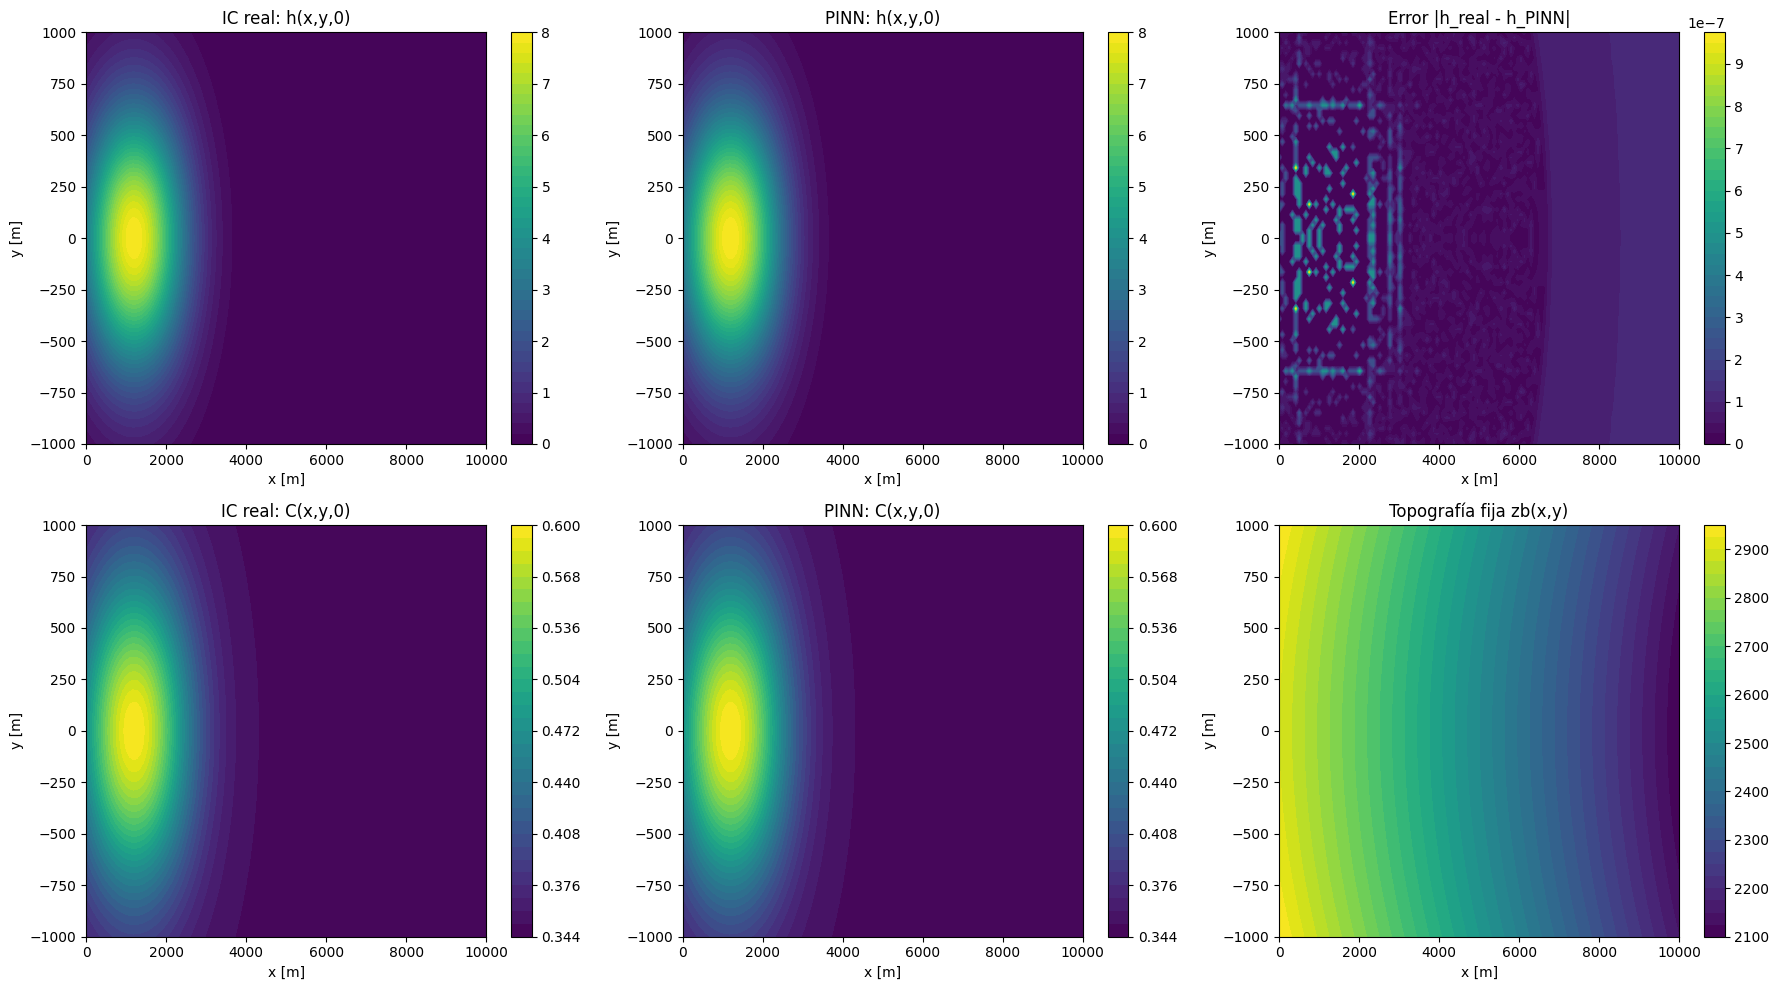

In [ ]:
# ============================================================
# 11) VERIFICACIÓN DE CONDICIÓN INICIAL
# ============================================================
nx, ny = 120, 80
xg = np.linspace(x_min, x_max, nx).astype(np.float32)
yg = np.linspace(y_min, y_max, ny).astype(np.float32)
X, Y = np.meshgrid(xg, yg, indexing='xy')

Xf = X.reshape(-1, 1)
Yf = Y.reshape(-1, 1)
T0 = np.zeros_like(Xf, dtype=np.float32)

h_pred0, u_pred0, v_pred0, C_pred0 = predict_fields(
    tf.convert_to_tensor(Xf),
    tf.convert_to_tensor(Yf),
    tf.convert_to_tensor(T0)
)

h0_map_pred = h_pred0.numpy().reshape(ny, nx)
C0_map_pred = C_pred0.numpy().reshape(ny, nx)
zb_map = zb0_physical(tf.convert_to_tensor(Xf), tf.convert_to_tensor(Yf)).numpy().reshape(ny, nx)

h0_map_true = ic_h_physical(tf.convert_to_tensor(Xf), tf.convert_to_tensor(Yf)).numpy().reshape(ny, nx)
C0_map_true = ic_C_physical(tf.convert_to_tensor(Xf), tf.convert_to_tensor(Yf)).numpy().reshape(ny, nx)

plt.figure(figsize=(18, 10))

plt.subplot(2, 3, 1)
plt.contourf(X, Y, h0_map_true, levels=40)
plt.title("IC real: h(x,y,0)")
plt.xlabel("x [m]"); plt.ylabel("y [m]")
plt.colorbar()

plt.subplot(2, 3, 2)
plt.contourf(X, Y, h0_map_pred, levels=40)
plt.title("PINN: h(x,y,0)")
plt.xlabel("x [m]"); plt.ylabel("y [m]")
plt.colorbar()

plt.subplot(2, 3, 3)
plt.contourf(X, Y, np.abs(h0_map_true - h0_map_pred), levels=40)
plt.title("Error |h_real - h_PINN|")
plt.xlabel("x [m]"); plt.ylabel("y [m]")
plt.colorbar()

plt.subplot(2, 3, 4)
plt.contourf(X, Y, C0_map_true, levels=40)
plt.title("IC real: C(x,y,0)")
plt.xlabel("x [m]"); plt.ylabel("y [m]")
plt.colorbar()

plt.subplot(2, 3, 5)
plt.contourf(X, Y, C0_map_pred, levels=40)
plt.title("PINN: C(x,y,0)")
plt.xlabel("x [m]"); plt.ylabel("y [m]")
plt.colorbar()

plt.subplot(2, 3, 6)
plt.contourf(X, Y, zb_map, levels=40)
plt.title("Topografía fija zb(x,y)")
plt.xlabel("x [m]"); plt.ylabel("y [m]")
plt.colorbar()

plt.tight_layout()
plt.show()


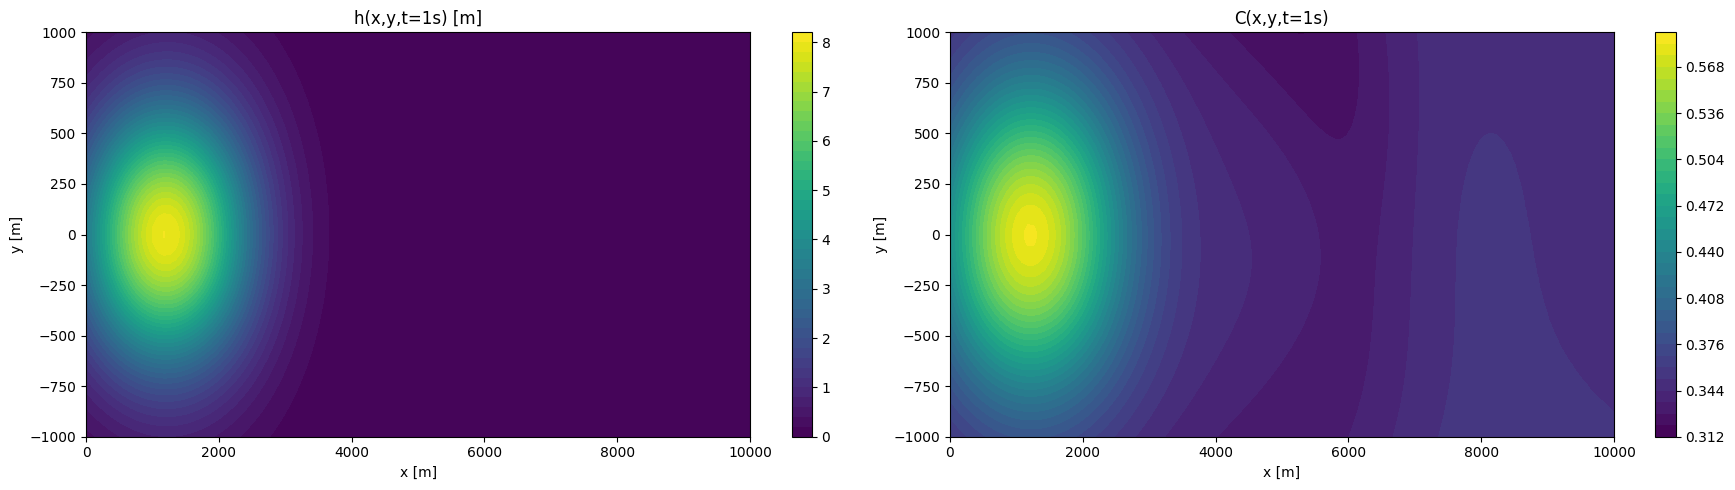

In [ ]:
# ============================================================
# 12) PREDICCIÓN EN t*
# ============================================================
t_star = 1.0
Tf = np.full_like(Xf, t_star, dtype=np.float32)

h_pred, u_pred, v_pred, C_pred = predict_fields(
    tf.convert_to_tensor(Xf),
    tf.convert_to_tensor(Yf),
    tf.convert_to_tensor(Tf)
)

h_map = h_pred.numpy().reshape(ny, nx)
C_map = C_pred.numpy().reshape(ny, nx)

plt.figure(figsize=(18, 5))

plt.subplot(1, 2, 1)
plt.contourf(X, Y, h_map, levels=40)
plt.title(f"h(x,y,t={t_star:.0f}s) [m]")
plt.xlabel("x [m]"); plt.ylabel("y [m]")
plt.colorbar()

plt.subplot(1, 2, 2)
plt.contourf(X, Y, C_map, levels=40)
plt.title(f"C(x,y,t={t_star:.0f}s)")
plt.xlabel("x [m]"); plt.ylabel("y [m]")
plt.colorbar()

plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.animation as animation
from IPython.display import HTML

t_min, t_max = 0.0, 1200.0
num_frames = 60 
t_values = np.linspace(t_min, t_max, num_frames)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 5))

# 2. Función de actualización para cada frame
def update(frame):
    ax1.clear()
    ax2.clear()
    
    t_star = t_values[frame]
    Tf = np.full_like(Xf, t_star, dtype=np.float32)
    
    h_pred, u_pred, v_pred, C_pred = predict_fields(
        tf.convert_to_tensor(Xf),
        tf.convert_to_tensor(Yf),
        tf.convert_to_tensor(Tf)
    )
    
    h_map = h_pred.numpy().reshape(ny, nx)
    C_map = C_pred.numpy().reshape(ny, nx)
    
    # --- PLOT ALTURA (h) ---
    c1 = ax1.contourf(X, Y, h_map, levels=40, cmap='viridis', vmin=0, vmax=8.0)
    ax1.set_title(f"Espesor (h) en t={t_star:.0f}s [m]")
    ax1.set_xlabel("x [m]"); ax1.set_ylabel("y [m]")
    
    # --- PLOT CONCENTRACIÓN (C) CORREGIDO ---
    
    # 1. Aplicar una máscara: Ignoramos concentraciones ínfimas (ruido numérico)
    # Solo ploteamos donde la concentración es mayor a 0.01 (1%)
    C_map_masked = np.ma.masked_where(C_map < 0.01, C_map)
    
    # 2. Usar una escala adaptativa sin vmax estricto para revelar la forma real
    # Le ponemos un color de fondo para la zona "limpia"
    ax2.set_facecolor('lightgrey') 
    
    # Ploteamos la máscara. Quitamos vmax para que Matplotlib se adapte a la escala real del pulso
    c2 = ax2.contourf(X, Y, C_map_masked, levels=20, cmap='plasma', vmin=0.01)
    
    ax2.set_title(f"Concentración (C) en t={t_star:.0f}s")
    ax2.set_xlabel("x [m]"); ax2.set_ylabel("y [m]")

# 3. Crear la animación
print("Generando animación, por favor espera...")
ani = animation.FuncAnimation(fig, update, frames=num_frames, interval=100)

# 4. Guardar y mostrar
# Opción A: Guardar como GIF (requiere tener 'pillow' instalado)
ani.save('lahar_evolucion.gif', writer='pillow', fps=10)
print("¡GIF guardado como 'lahar_evolucion.gif'!")

# Opción B: Mostrarlo como un video interactivo en el mismo Jupyter Notebook
plt.close() # Evita que se imprima un plot vacío extra
display(HTML(ani.to_jshtml()))

Generando animación, por favor espera...
¡GIF guardado como 'lahar_evolucion.gif'!


# Por hacer
- fijar el pulso en el centro del plot, 500,0
- agregar la dem
- comparar con el mapa del evento
- usar los primeros 100s
- usar valle gausiano